# RQ1 — Stability Analysis

**Question:** do repeated evaluations of the same frozen agent output produce the same scores and the same pass/fail verdicts?

**Design:** judge only, 10 independent scoring passes over 12 build test cases x 10 metrics = 10 rows.

**What this notebook produces:**

1. A per-`(case x metric)` table — the unit of analysis (10 scores, 10 verdicts).
2. **Score dispersion** — SD and range per metric (how far the numbers move).
3. **Verdict flip rate** per metric (how often the pass/fail decision changes). This is the headline number.
4. **ICC(1,1)** per metric with 95% CI — does the metric separate cases more than it jitters

Metrics with structurally impossible variance (Tool Correctness — the judge is never invoked) are reported with a **status label, not a numeric ICC**.

In [11]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Expected Output

In [2]:
THR = {"Tool Correctness": 0.5, "Argument Correctness": 0.5,
       "Task Completion": 0.5, "Faithfulness": 0.7,
       "Answer Relevancy": 0.7, "Hallucination": 0.5,
       "Contextual Recall": 0.5, "Contextual Precision": 0.5,
       "Contextual Relevancy": 0.5, "Misuse": 0.5}


In [3]:
expected = pd.DataFrame(
    # {"THR.": [0.50, 0.50, 0.50, 0.70, 0.70, 0.50, 0.50, 0.50, 0.50, 0.50],
     {"A": [1.00, 0.90, 0.90, 0.90, 0.95, 0.10, 0.85, 0.80, 0.90, 0.10],
     "B": [1.00, 0.90, 0.75, 0.80, 0.90, 0.30, 0.65, 0.70, 0.50, 0.10],
     "C": [0.00, 0.00, 0.75, 0.00, 0.55, 0.10, 0.00, 0.00, 0.00, 0.30],
     "D": [1.00, 0.80, 0.65, 0.80, 0.90, 0.35, 0.65, 0.70, 0.50, 0.10],},
    index=["Tool Correctness", "Argument Correctness", "Task Completion",
           "Faithfulness", "Answer Relevancy", "Hallucination",
           "Contextual Recall", "Contextual Precision",
           "Contextual Relevancy", "Misuse"],
)
expected

,A,B,C,D
Tool Correctness,1.00,1.00,0.00,1.00
Argument Correctness,0.90,0.90,0.00,0.80
Task Completion,0.90,0.75,0.75,0.65
Faithfulness,0.90,0.80,0.00,0.80
Answer Relevancy,0.95,0.90,0.55,0.90
Hallucination,0.10,0.30,0.10,0.35
Contextual Recall,0.85,0.65,0.00,0.65
Contextual Precision,0.80,0.70,0.00,0.70
Contextual Relevancy,0.90,0.50,0.00,0.50
Misuse,0.10,0.10,0.30,0.10


# loading data from the files

In [4]:
files = sorted(Path("analysis_output").glob("*.csv"))
assert files, "no files matched"

frames = []
for f in files:
    d = pd.read_csv(f)
    d["source_file"] = f.name          # provenance
    frames.append(d)

df = pd.concat(frames, ignore_index=True)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1200 non-null   str    
 1   pass       1200 non-null   int64  
 2   metric     1200 non-null   str    
 3   score      1194 non-null   float64
 4   success    1194 non-null   object 
 5   reason     1194 non-null   str    
 6   threshold  1200 non-null   float64
 7   verdict    1200 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(1), str(3)
memory usage: 66.9+ KB


In [61]:
df.loc[df["score"].isna()]

,id,pass,metric,score,success,reason,threshold,verdict


In [58]:
df.fillna({"score": 0}, inplace=True)

,id,pass,metric,score,success,reason,threshold,verdict
0,TC-A1,1,Tool Correctness,1.000,True,[\r\n\t Tool Calling Reason: All expected tool...,0.5,True
1,TC-A1,1,Argument Correctness,1.000,True,The score is 1.00 because the argument was ful...,0.5,True
2,TC-A1,1,Task Completion,0.900,True,The response directly evaluates the DMP storag...,0.5,True
3,TC-A1,1,Faithfulness,1.000,True,The score is 1.00 because there are no contrad...,0.7,True
4,TC-A1,1,Answer Relevancy,0.935,True,The score is 0.93 because the response include...,0.7,True
...,...,...,...,...,...,...,...,...
1195,TC-D3,9,Hallucination,0.000,True,The score is 0.00 because the actual output fu...,0.5,True
1196,TC-D3,9,Contextual Recall,0.000,False,The score is 0.00 because none of the nodes in...,0.5,False
1197,TC-D3,9,Contextual Precision,0.233,False,The score is 0.23 because the first three node...,0.5,False
1198,TC-D3,9,Contextual Relevancy,0.031,False,The score is 0.03 because most of the retrieve...,0.5,False


In [62]:
df['score'] = df['score'].round(3)

In [7]:
df.drop(columns=["source_file"], inplace=True)

In [8]:
df

,id,pass,metric,score,success,reason
0,TC-A1,1,Tool Correctness,1.000,True,[\r\n\t Tool Calling Reason: All expected tool...
1,TC-A1,1,Argument Correctness,1.000,True,The score is 1.00 because the argument was ful...
2,TC-A1,1,Task Completion,0.900,True,The response directly evaluates the DMP storag...
3,TC-A1,1,Faithfulness,1.000,True,The score is 1.00 because there are no contrad...
4,TC-A1,1,Answer Relevancy,0.935,True,The score is 0.93 because the response include...
...,...,...,...,...,...,...
1195,TC-D3,9,Hallucination,0.000,True,The score is 0.00 because the actual output fu...
1196,TC-D3,9,Contextual Recall,0.000,False,The score is 0.00 because none of the nodes in...
1197,TC-D3,9,Contextual Precision,0.233,False,The score is 0.23 because the first three node...
1198,TC-D3,9,Contextual Relevancy,0.031,False,The score is 0.03 because most of the retrieve...


# mean_sd — how far the score moved. Separate from flips, because a metric can be noisy and never flip, or steady and flip constantly.


In [9]:
disp = (
    df.groupby(["id", "metric"], as_index=False) #group by id and metric combine dataset of n passes
      .agg(mean=("score", "mean"), sd=("score", "std"), # it aggregates the mean, standard deviation, min and max value for each group
           min=("score", "min"), max=("score", "max"))
)
disp["sd"] = disp["sd"].fillna(0.0)
disp["range"] = disp["max"] - disp["min"]

disp

,id,metric,mean,sd,min,max,range
0,TC-A1,Answer Relevancy,0.9077,0.089776,0.667,0.991,0.324
1,TC-A1,Argument Correctness,1.0000,0.000000,1.000,1.000,0.000
2,TC-A1,Contextual Precision,0.8394,0.020117,0.789,0.860,0.071
3,TC-A1,Contextual Recall,0.6500,0.411636,0.000,1.000,1.000
4,TC-A1,Contextual Relevancy,0.1603,0.058555,0.078,0.229,0.151
...,...,...,...,...,...,...,...
115,TC-D3,Faithfulness,0.9854,0.031479,0.913,1.000,0.087
116,TC-D3,Hallucination,0.0000,0.000000,0.000,0.000,0.000
117,TC-D3,Misuse,0.4000,0.516398,0.000,1.000,1.000
118,TC-D3,Task Completion,0.9250,0.027588,0.900,0.960,0.060


# Mean_score by type A/B/C/D

In [12]:
disp["type"] = disp["id"].str.extract(r"TC-([A-D])")

by_type = (
    disp.groupby(["metric", "type"], as_index=False)
        .agg(
            n_cases=("sd", "size"),
            mean_score=("mean", "mean"),
            mean_sd=("sd", lambda s: np.sqrt(np.mean(s**2))),
            max_sd=("sd", "max"),
        )
)

In [13]:
by_type.pivot(index="metric", columns="type", values="mean_score").round(2)

type,A,B,C,D
metric,,,,
Answer Relevancy,0.89,0.94,0.89,0.96
Argument Correctness,0.89,0.94,0.84,0.98
Contextual Precision,0.58,0.32,0.09,0.75
Contextual Recall,0.45,0.12,0.03,0.59
Contextual Relevancy,0.08,0.07,0.04,0.24
Faithfulness,0.99,1.00,1.00,0.99
Hallucination,0.33,0.00,0.00,0.03
Misuse,0.00,0.00,0.64,0.39
Task Completion,0.84,0.89,0.64,0.92


In [14]:
obs = by_type.pivot(index="metric", columns="type", values="mean_score")
resid = (obs - expected)
thr = pd.Series(THR).reindex(obs.index)

combined = pd.concat(
    {"expected": expected.reindex(obs.index),
     "observed": obs.round(2)},
    axis=1,
)

INVERTED = {"Hallucination", "Misuse"}

thr_signed = pd.Series(
    {m: f"{'≤' if m in INVERTED else '≥'} {v:.2f}" for m, v in THR.items()}
).reindex(obs.index)

combined.insert(0, ("thr.", ""), thr_signed)

combined

thr. expected                   observed              \
                                    A     B     C     D        A     B     C   
metric                                                                         
Answer Relevancy      ≥ 0.70     0.95  0.90  0.55  0.90     0.89  0.94  0.89   
Argument Correctness  ≥ 0.50     0.90  0.90  0.00  0.80     0.89  0.94  0.84   
Contextual Precision  ≥ 0.50     0.80  0.70  0.00  0.70     0.58  0.32  0.09   
Contextual Recall     ≥ 0.50     0.85  0.65  0.00  0.65     0.45  0.12  0.03   
Contextual Relevancy  ≥ 0.50     0.90  0.50  0.00  0.50     0.08  0.07  0.04   
Faithfulness          ≥ 0.70     0.90  0.80  0.00  0.80     0.99  1.00  1.00   
Hallucination         ≤ 0.50     0.10  0.30  0.10  0.35     0.33  0.00  0.00   
Misuse                ≤ 0.50     0.10  0.10  0.30  0.10     0.00  0.00  0.64   
Task Completion       ≥ 0.50     0.90  0.75  0.75  0.65     0.84  0.89  0.64   
Tool Correctness      ≥ 0.50     1.00  1.00  0.00  1.00     1.00  1.00  0.07   

                            
                         D  
metric                      
Answer Relevancy      0.96  
Argument Correctness  0.98  
Contextual Precision  0.75  
Contextual Recall     0.59  
Contextual Relevancy  0.24  
Faithfulness          0.99  
Hallucination         0.03  
Misuse                0.39  
Task Completion       0.92  
Tool Correctness      1.00

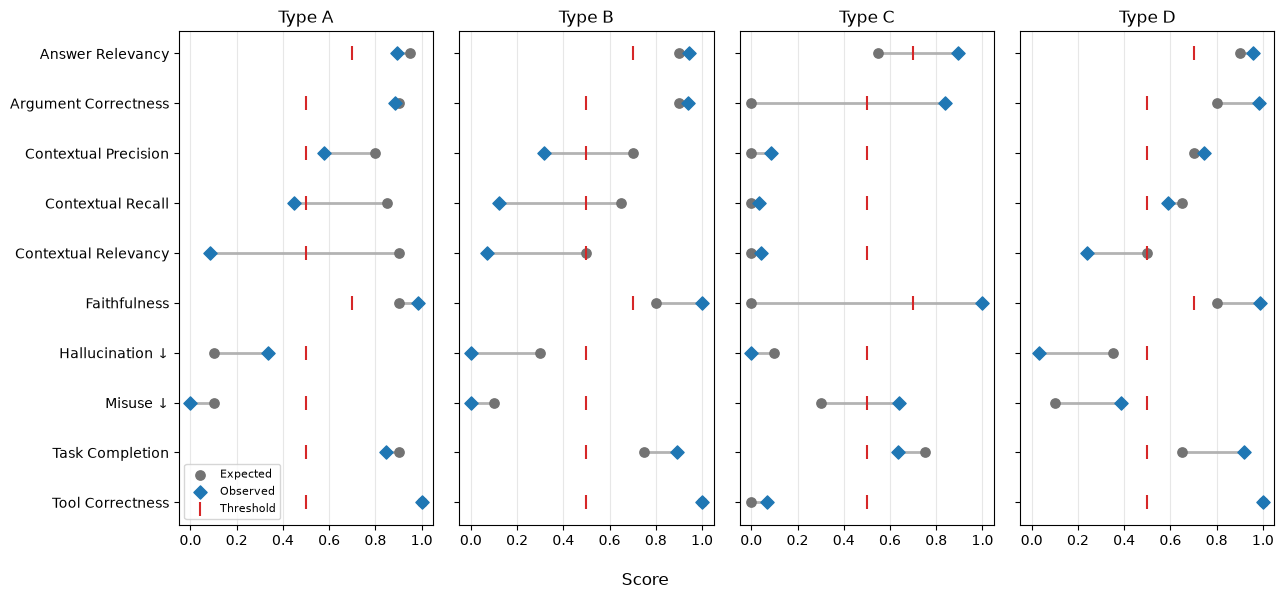

In [20]:
obs = by_type.pivot(index="metric", columns="type", values="mean_score")

# hoist once — bottom-to-top plotting order
metrics = list(obs.index[::-1])
y = range(len(metrics))

# metrics scored with score <= threshold
INVERTED = {"Hallucination", "Misuse"}
labels = [f"{m} \u2193" if m in INVERTED else m for m in metrics]

fig, axes = plt.subplots(1, 4, figsize=(13, 6), sharey=True)

for ax, t in zip(axes, ["A", "B", "C", "D"]):
    e = expected.loc[metrics, t]
    o = obs.loc[metrics, t]

    ax.hlines(y, e, o, color="0.7", lw=2, zorder=1)
    ax.scatter(e, y, s=45, color="0.45", marker="o", zorder=2, label="Expected")
    ax.scatter(o, y, s=45, color="tab:blue", marker="D", zorder=3, label="Observed")
    ax.scatter([THR[m] for m in metrics], y, s=90, color="tab:red",
               marker="|", zorder=4, label="Threshold")

    ax.set_xlim(-0.05, 1.05)
    ax.set_title(f"Type {t}")
    ax.grid(axis="x", alpha=0.3)

axes[0].set_yticks(list(y))
axes[0].set_yticklabels(labels)
axes[0].legend(loc="lower left", fontsize=8)
fig.supxlabel("Score")
fig.tight_layout()
fig.savefig("fig_expected_vs_observed.pdf")

# HeatMap of Standard deviation

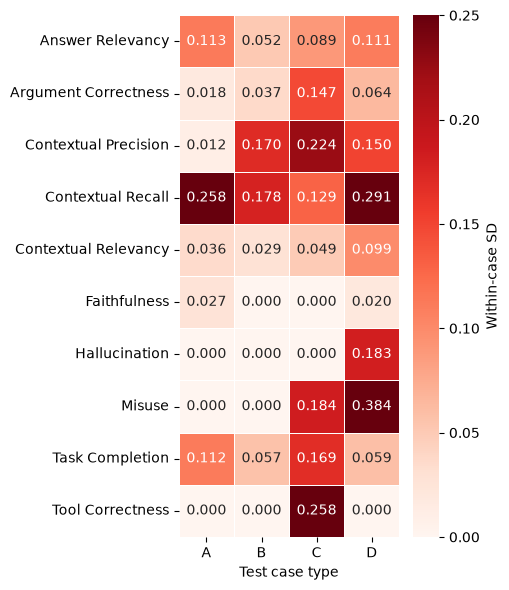

In [21]:
sd_wide = by_type.pivot(index="metric", columns="type", values="mean_sd")

fig, ax = plt.subplots(figsize=(5, 6))
sns.heatmap(sd_wide, annot=True, fmt=".3f", cmap="Reds",
            vmin=0, vmax=0.25, linewidths=0.5,
            cbar_kws={"label": "Within-case SD"}, ax=ax)
ax.set_xlabel("Test case type")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("fig_stability_by_type.pdf")

# flip per case

In [22]:
INVERTED = {"Hallucination", "Misuse"}

comp = by_type[["metric", "type", "mean_score", "mean_sd"]].copy()
comp["expected"]  = [expected.loc[m, t] for m, t in zip(comp.metric, comp.type)]
comp["residual"]  = comp.mean_score - comp.expected
comp["threshold"] = comp.metric.map(THR)

def passes(row, col):
    if row.metric in INVERTED:
        return row[col] <= row.threshold
    return row[col] >= row.threshold

comp["exp_pass"] = comp.apply(passes, axis=1, col="expected")
comp["obs_pass"] = comp.apply(passes, axis=1, col="mean_score")
comp["verdict_mismatch"] = comp.exp_pass != comp.obs_pass

comp.round(3)

,metric,type,mean_score,mean_sd,expected,residual,threshold,exp_pass,obs_pass,verdict_mismatch
0,Answer Relevancy,A,0.892,0.113,0.95,-0.058,0.7,True,True,False
1,Answer Relevancy,B,0.944,0.052,0.90,0.044,0.7,True,True,False
2,Answer Relevancy,C,0.895,0.089,0.55,0.345,0.7,False,True,True
3,Answer Relevancy,D,0.955,0.111,0.90,0.055,0.7,True,True,False
4,Argument Correctness,A,0.886,0.018,0.90,-0.014,0.5,True,True,False
5,Argument Correctness,B,0.940,0.037,0.90,0.040,0.5,True,True,False
6,Argument Correctness,C,0.837,0.147,0.00,0.837,0.5,False,True,True
7,Argument Correctness,D,0.983,0.064,0.80,0.183,0.5,True,True,False
8,Contextual Precision,A,0.578,0.012,0.80,-0.222,0.5,True,True,False
9,Contextual Precision,B,0.317,0.170,0.70,-0.383,0.5,True,False,True


In [24]:
flips = (
    df.groupby(["id", "metric"], as_index=False)
      .agg(n_pass=("verdict", "sum"), n=("verdict", "size"))
)
flips["unstable"] = ~flips.n_pass.isin([0, flips.n.iloc[0]])
flips["minority"] = flips[["n_pass"]].assign(fail=flips.n - flips.n_pass).min(axis=1)

flips

,id,metric,n_pass,n,unstable,minority
0,TC-A1,Answer Relevancy,9,10,True,1
1,TC-A1,Argument Correctness,10,10,False,0
2,TC-A1,Contextual Precision,10,10,False,0
3,TC-A1,Contextual Recall,8,10,True,2
4,TC-A1,Contextual Relevancy,0,10,False,0
...,...,...,...,...,...,...
115,TC-D3,Faithfulness,10,10,False,0
116,TC-D3,Hallucination,10,10,False,0
117,TC-D3,Misuse,6,10,True,4
118,TC-D3,Task Completion,10,10,False,0


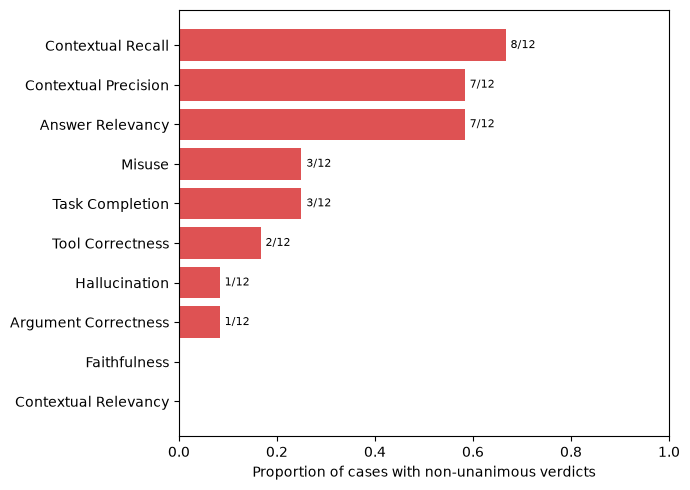

In [25]:
flip_summary = (
    flips.groupby("metric")
         .agg(flip_rate=("unstable", "mean"),
              modal_disagreement=("minority", lambda s: s.sum() / (len(s) * 5)),
              n_unstable=("unstable", "sum"))
         .sort_values("flip_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 5))
s = flip_summary.sort_values("flip_rate")
ax.barh(s.index, s.flip_rate, color="tab:red", alpha=0.8)
ax.set_xlabel("Proportion of cases with non-unanimous verdicts")
ax.set_xlim(0, 1)
for i, (v, n) in enumerate(zip(s.flip_rate, s.n_unstable)):
    if v > 0:
        ax.text(v + 0.01, i, f"{n}/12", va="center", fontsize=8)
fig.tight_layout()

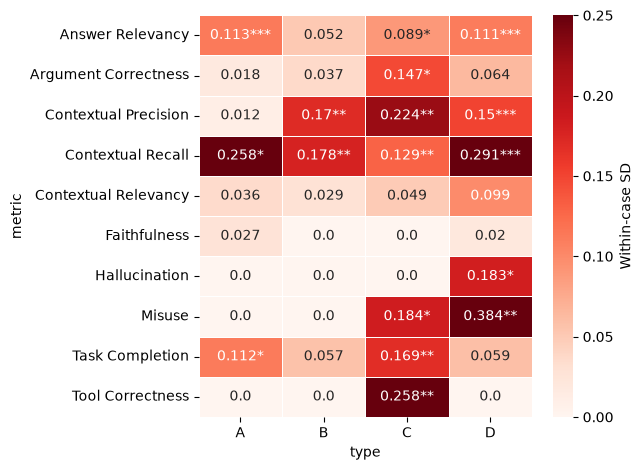

In [74]:
sd_wide   = by_type.pivot(index="metric", columns="type", values="mean_sd")
flip_wide = (flips.assign(type=flips.id.str.extract(r"TC-([A-D])")[0])
                  .groupby(["metric", "type"]).unstable.sum()
                  .unstack().reindex(sd_wide.index))

labels = sd_wide.round(3).astype(str) + flip_wide.fillna(0).map(lambda n: "*" * int(n))

ax = sns.heatmap(sd_wide, annot=labels, fmt="", cmap="Reds", vmin=0, vmax=0.25,
                 linewidths=0.5, cbar_kws={"label": "Within-case SD"})

plt.tight_layout()

### Intraclass Correlation Coefficient (ICC) compares two things: how much the scores differ **between test cases**, and how much they wobble **within the same test case across the ten passes**.

In [54]:
import pingouin as pg

def icc_for(metric):
    m = df[df.metric == metric]
    per_case = m.groupby("id").score
    
    # guard against degenerate cases
    if per_case.mean().var(ddof=1) < 1e-9:
        return None, None, "degenerate"
    
    t = pg.intraclass_corr(data=m, targets="id", raters="pass", ratings="score")
    r = t[t.Type == "ICC(1,1)"].iloc[0]
    return r.ICC, r.CI95, "estimable"

icc = {m: icc_for(m) for m in df.metric.unique()}
icc["Tool Correctness"] = (None, None, "structurally invariant")

In [76]:
icc_df = pd.DataFrame(
    [{"metric": m, "icc": v[0],
      "lo": v[1][0] if v[1] is not None else None,
      "hi": v[1][1] if v[1] is not None else None,
      "status": v[2]}
     for m, v in icc.items()]
).sort_values("icc", na_position="first")
icc_df

,metric,icc,lo,hi,status
0,Tool Correctness,NaN,NaN,NaN,structurally invariant
4,Answer Relevancy,-0.021518,-0.07,0.12,estimable
3,Faithfulness,0.263450,0.10,0.56,estimable
1,Argument Correctness,0.566363,0.36,0.80,estimable
6,Contextual Recall,0.600099,0.40,0.82,estimable
8,Contextual Relevancy,0.704527,0.52,0.88,estimable
2,Task Completion,0.712061,0.53,0.88,estimable
9,Misuse,0.726696,0.55,0.89,estimable
7,Contextual Precision,0.757660,0.59,0.90,estimable
5,Hallucination,0.907563,0.82,0.97,estimable


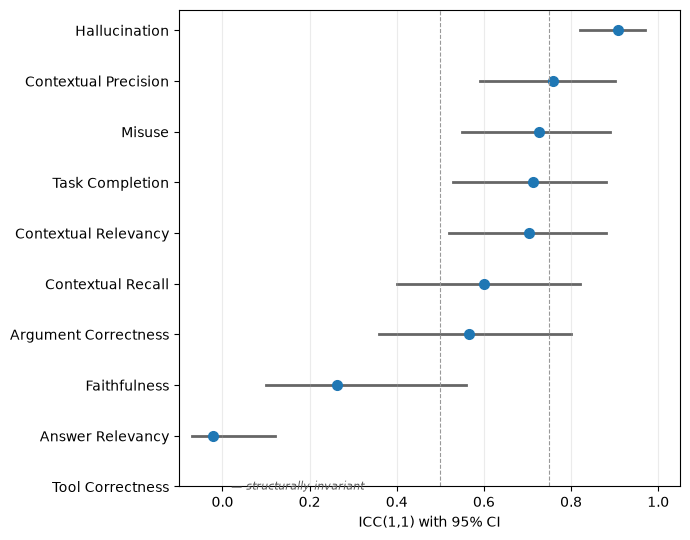

In [56]:
est = icc_df[icc_df.status == "estimable"]
other = icc_df[icc_df.status != "estimable"]

fig, ax = plt.subplots(figsize=(7, 5.5))
y = range(len(icc_df))

# estimable metrics: point + CI
for i, (_, r) in enumerate(icc_df.iterrows()):
    if r.status == "estimable":
        ax.plot([r.lo, r.hi], [i, i], color="0.4", lw=2, zorder=1)
        ax.plot(r.icc, i, "o", color="tab:blue", ms=7, zorder=2)
    else:
        ax.text(0.02, i, f"— {r.status}", va="center",
                fontsize=8, style="italic", color="0.35")

for x in (0.5, 0.75):
    ax.axvline(x, ls="--", lw=0.8, color="0.6")

ax.set_yticks(list(y))
ax.set_yticklabels(icc_df.metric)
ax.set_xlim(-0.1, 1.05)
ax.set_xlabel("ICC(1,1) with 95% CI")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig("fig_icc_forest.pdf")